#**CHAPTER 3.BAYESIAN TRANSFORMERS**
---

##REFERENCE

https://chatgpt.com/share/69acbf2d-db54-8012-891c-6d9bb26e90d9

##0.CONTEXT

**Introduction**

Bayesian transformers bring together two of the most important ideas in modern machine learning. The first is the transformer architecture, which has become one of the dominant frameworks for sequence modeling because of its ability to represent long-range dependencies through self-attention. The second is Bayesian inference, which provides a disciplined way to represent uncertainty, update beliefs from data, and avoid the dangerous habit of acting as though a trained model is automatically certain about what it has learned. When these two ideas are combined, the result is not merely a transformer that produces probability distributions over tokens. A standard transformer language model already does that. Instead, a Bayesian transformer is a transformer in which uncertainty is embedded into the model parameters themselves, so that prediction becomes an average over many plausible parameter settings rather than one deterministic computation through a single frozen network.

To understand why this matters, it helps to begin with the ordinary transformer. In a standard transformer language model, the input sequence is converted into token embeddings and positional embeddings, then passed through blocks of self-attention and feed-forward transformations. These layers use learned weight matrices to project token representations into queries, keys, values, and hidden transformations. Training adjusts the parameters so that the model becomes better at predicting the next token in a sequence. Once training is finished, those parameters are treated as fixed. If the model sees a prefix such as “open red then,” it computes the logits for the next token and produces a softmax distribution over the vocabulary. That distribution is often interpreted as uncertainty, but this interpretation is incomplete. It reflects the model’s output under one learned parameter setting. It does not necessarily reflect uncertainty about whether those parameters themselves are well supported by the evidence.

This distinction is especially important in text prediction because language-like sequence data often contain ambiguity at multiple levels. A prefix may genuinely allow several plausible continuations. A training corpus may only weakly constrain the model in some contexts. Some token combinations may be rare, noisy, or corrupted. Some grammar families may overlap. A deterministic transformer may still produce a sharp next-token distribution because its parameters are fixed. A Bayesian transformer can instead express uncertainty arising from the model itself. If different plausible settings of the transformer’s weights disagree about what the next token should be, then the predictive distribution should become broader. This is one of the major attractions of Bayesian deep learning in sequence modeling.

The notebook we generated is a very good setting for understanding this idea because it uses synthetic text prediction rather than natural language scraped from the world. That is not a weakness. It is a major pedagogical strength. Real natural language is enormously rich, messy, and historically contingent. If one tried to explain Bayesian transformers using a large real corpus immediately, the student would face too many confounding factors at once. Instead, the notebook constructs several controlled grammar families. Each family generates sequences with a specific pattern logic. Some alternate token pairs. Some cycle through token triplets. Some produce mirrored structures. Some use marker-based patterns such as open, inner structure, and close. This creates a sequence domain that is easy to inspect, yet nontrivial enough to support meaningful uncertainty analysis.

The use of synthetic grammar families gives us something precious in machine learning: visibility into the data-generating process. We know what the grammars are, we know which family generated each sequence, and we know how the sequences are corrupted. That means we can interpret uncertainty scientifically rather than only impressionistically. If the Bayesian transformer becomes uncertain after a certain prefix, we can ask whether that uncertainty makes sense relative to the grammar overlap or corruption noise. If the model confuses one next-token continuation with another, we can inspect the exact synthetic sequence logic that led to the confusion. This is much harder to do in real language, where ambiguity is vast and labels are less clean.

Another strength of the notebook’s design is that the synthetic sequences are not perfectly clean. Controlled corruption is added in the form of token substitutions and motif noise. This is extremely important. If the synthetic corpus contained only pristine grammar realizations, then next-token prediction would quickly become too easy, and uncertainty would not be very interesting. The Bayesian transformer might simply become highly confident everywhere. By introducing corruption, the notebook creates situations in which the continuation is less obvious. A marker pattern may be disrupted. A cyclic triplet may be partially broken. A mirrored pattern may begin to look like another family. These are exactly the kinds of local ambiguities that make Bayesian uncertainty visible.

At a conceptual level, Bayesian transformers extend the same logic that we saw in Bayesian neural networks for images. In an ordinary transformer, the projection matrices in attention and feed-forward layers are point estimates. In a Bayesian transformer, those matrices are uncertain and represented by variational distributions. That means a forward pass through the model is not just a deterministic function evaluation. It is one sample from a family of plausible transformers. Running the model multiple times on the same prefix, each time sampling different weights from the approximate posterior, gives a set of slightly different predictions. Averaging those predictions yields the posterior predictive distribution for the next token.

This is a profound shift in interpretation. In ordinary language modeling, a probability vector over the next token is often read as “the model’s belief.” But that vector may reflect only one chosen parameter point. In a Bayesian transformer, the predictive vector is instead the result of integrating over parameter uncertainty, at least approximately. This allows the model to say not only which token is most likely, but also how stable that judgment is across plausible parameter realizations. If sampled transformers strongly agree, the prediction is likely robust. If they disagree, then predictive entropy rises, and the model is telling us that it has not learned a uniquely stable continuation rule for that prefix.

This matters because transformers are powerful but can also be deceptively overconfident. A deterministic transformer trained on noisy or narrow data may still output a highly peaked softmax distribution even in contexts where the evidence is weak. This is one of the reasons Bayesian approaches are attractive. They provide a way of turning parameter uncertainty into predictive uncertainty. In sequence modeling, that can be very useful. Some prefixes may be very common in the training corpus and therefore strongly constrain the posterior. Other prefixes may occur less often, or under mixed grammar families, leading to a wider posterior predictive distribution. In a scientific notebook, this can be studied directly through Monte Carlo forward passes and entropy plots.

The mathematical core of the Bayesian transformer notebook is variational inference. Exact posterior inference in a transformer is intractable for the same reason it is intractable in other deep models: the parameter space is huge and the likelihood surface is highly nonlinear. So instead of attempting exact Bayesian learning, the notebook uses a practical approximation. Each Bayesian linear layer learns a mean and a scale-related parameter for every weight and bias. During the forward pass, the model samples concrete weight values using the reparameterization trick. During training, it optimizes a loss that combines predictive fit with KL divergence against a Gaussian prior. This is conceptually similar to Bayes by Backprop in Bayesian neural networks, but now embedded inside self-attention and transformer blocks.

The role of the KL term is worth emphasizing. In a deterministic transformer, one usually minimizes cross-entropy on the training sequences. In the Bayesian transformer, one minimizes an ELBO-style objective that includes both a negative log-likelihood term and a KL regularization term. The negative log-likelihood rewards the model for predicting the next token correctly. The KL term penalizes the posterior for drifting too far from the prior without sufficient evidence. In effect, the model is encouraged to fit the data, but only with as much certainty as the evidence supports. This is one of the most intellectually attractive features of Bayesian deep learning. It turns regularization from a heuristic into a probabilistic principle.

Another key point is that uncertainty in sequence models can arise for more than one reason. A prefix may be uncertain because the data-generating grammar genuinely allows multiple continuations. That is a kind of task ambiguity. But a prefix may also be uncertain because the model has not learned enough from the data, because the training corpus is sparse in that region, or because corruption has made the context less informative. Bayesian transformers are especially concerned with the second type of issue: uncertainty about the learned mapping itself. By sampling from the posterior approximation over weights, the model can expose disagreement among plausible internal parameter settings. This produces a richer understanding of uncertainty than a single deterministic softmax can usually provide.

The notebook is also designed to emphasize visualization, and this is exactly the right pedagogical choice. Sequence modeling can feel abstract because so much of the action happens inside embeddings and attention maps that are not immediately intuitive. But uncertainty becomes easier to understand when displayed through sample sequences, token frequency heatmaps, training curves, entropy histograms, confusion matrices, and probability bar charts for specific prefixes. A prefix such as “open alpha and” can be shown next to the model’s predictive distribution over possible next tokens. When that distribution is sharp, the student sees a confident continuation. When it is broad, the student sees ambiguity directly. This makes Bayesian inference tangible.

The grammar families in the notebook are especially helpful for teaching attention itself. Alternating pairs and cyclic triplets create strong local regularities. Mirrored structures introduce longer-range dependencies because the end of the pattern reflects earlier tokens. Marker-based patterns create structural framing, with tokens such as open and close shaping what should happen in the middle. A transformer is a natural model for these problems because self-attention can, in principle, connect relevant tokens across the sequence regardless of distance. By making the transformer Bayesian, the notebook asks not only whether self-attention can learn these grammar families, but whether the model can express uncertainty when the sequence evidence becomes noisy or mixed.

There is also a broader lesson here about what Bayesian transformers could mean beyond synthetic data. In real-world applications, text prediction and sequence modeling often occur under uncertainty. In finance, sequences may describe market states, event streams, order-flow dynamics, transaction histories, or structured text and numerical hybrids. In operations, sequences may describe machine states or logs. In medicine, they may describe clinical events. In all such settings, a model that predicts the next event or classifies a sequence while also expressing uncertainty about its own learned structure can be much more useful than a deterministic system that is sharply confident everywhere. Bayesian transformers offer one principled route toward that goal.

At the same time, it is important to be honest about their limitations. The posterior learned in a notebook like this is approximate, not exact. The variational family is relatively simple and may underestimate true posterior complexity. The transformer is small, not industrial scale. The corpus is synthetic, not a real-world language dataset. But these are not defects in the educational sense. They are precisely what make the notebook useful for study. The notebook isolates the key mechanisms of Bayesian sequence modeling in a form that can be run, visualized, and interpreted end to end.

That is the deeper value of Bayesian transformers as a topic. They force us to rethink what sequence modeling should mean. Instead of saying that a transformer has learned a next-token rule, we ask which family of transformers remains plausible given the evidence and what those plausible transformers jointly imply for prediction. That is a richer and more intellectually honest notion of learning. It places uncertainty at the center rather than at the margins.

So the notebook is doing something bigger than just predicting synthetic tokens. It is showing how the modern transformer architecture can be reinterpreted through a Bayesian lens. It is demonstrating that even in sequence models, parameter uncertainty can be made visible, predictive distributions can be made richer, and ambiguous prefixes can be treated as opportunities for probabilistic reasoning rather than as mere errors. In that sense, Bayesian transformers are not simply a specialized research topic. They are part of a broader movement toward machine learning systems that are more reflective about what they know and what they do not know.

That is why they matter. A Bayesian transformer is not just a transformer with noise in its weights. It is a transformer that refuses to pretend that training erased uncertainty. And in modern AI, that refusal is an important form of scientific maturity.

##1.LIBRARIES AND ENVIRONMENT

**Cell 1 Explanation**

Cell 1 sets up the computational and experimental environment for the Bayesian transformer notebook. At first glance, it may look like an ordinary setup cell, but pedagogically it performs several foundational roles that shape everything that follows.

The most important idea introduced here is reproducibility. The notebook sets deterministic random seeds for Python, NumPy, and PyTorch. This is particularly important in a Bayesian transformer experiment because randomness appears in multiple places. The synthetic data generator uses randomness to select grammar variations and corruption. The Bayesian linear layers sample weights during training and inference. Data are shuffled in minibatches. Without careful seed setting, the same notebook could produce noticeably different runs, making interpretation more difficult. By controlling the seeds, the notebook becomes a stable scientific object rather than a moving target.

The second important function of this cell is to establish the computational device. The notebook checks whether a GPU is available and otherwise uses CPU. This is standard good practice, but it is especially useful in Colab because different sessions may have different hardware. Even though this notebook is compact enough to run on CPU, writing the code in a device-aware way makes it portable and professional.

The selection of libraries is another important design choice. Only a small set of essential packages is used: NumPy, Matplotlib, PyTorch, and a few standard Python utilities such as json and pathlib. This minimalism is pedagogically valuable. It keeps attention on the Bayesian transformer itself rather than on a large software ecosystem. Students can inspect the core mechanics directly.

The artifact directory created in this cell is also significant. It gives the notebook a place to save metadata, training history, and final results. This is part of a more serious experimental culture. Instead of simply printing outputs and forgetting them, the notebook preserves structured results for later inspection.

Finally, the plotting defaults matter because this notebook relies heavily on visualization. Setting figure sizes, grid transparency, and font size at the beginning ensures consistency across all later charts.

So Cell 1 is more than setup. It defines the notebook’s scientific discipline: reproducible, lightweight, device-aware, artifact-saving, and visualization-oriented. It establishes the culture in which Bayesian sequence modeling will be studied.

In [1]:
# Cell 1
# Environment setup, imports, seeds, plotting defaults, artifact directory

import math
import json
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

SEED = 321
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ARTIFACT_DIR = Path("bayesian_transformer_text_artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["font.size"] = 11

print("Bayesian Transformers for Synthetic Text Prediction")
print("Seed:", SEED)
print("Device:", DEVICE)
print("Artifacts:", ARTIFACT_DIR.resolve())

Bayesian Transformers for Synthetic Text Prediction
Seed: 321
Device: cpu
Artifacts: /content/bayesian_transformer_text_artifacts


##2.VOCABULARY DEFINITION

###2.1.OVERVIEW

**Cell 2 Explanation**

Cell 2 defines the synthetic sequence world that the Bayesian transformer will learn to model. Pedagogically, this is one of the most important cells in the notebook because it determines what kinds of regularities, ambiguities, and uncertainties the model will encounter.

The cell begins by defining the vocabulary. There are special tokens for padding, sequence beginning, and end of sequence, along with a small but expressive content vocabulary. This is a very good design choice because it keeps the token space small enough to visualize and reason about while still allowing structured grammar families. A small vocabulary makes uncertainty analysis much clearer. When the model predicts the next token, the reader can inspect a manageable distribution rather than a huge opaque one.

The grammar families are the true conceptual center of the cell. There are alternating pairs, cyclic triplets, mirrored structures, and marker-based patterns. Each grammar family produces sequences with its own structural logic. Alternating pairs create immediate repetition patterns. Cyclic triplets introduce three-step periodicity. Mirrored structures create symmetry and longer-range dependence. Marker patterns introduce tokens like open and close that impose structural expectations over the whole sequence. This diversity is important because it creates a task that is more interesting than simple token repetition.

The clean and noisy sequence generation is especially instructive. Every grammar family can produce a clean prototype sequence, but corruption is then introduced through token substitution. This is pedagogically essential. If every sequence were generated perfectly, next-token prediction would quickly become too easy, and the Bayesian transformer’s uncertainty would not be very informative. By adding corruption, the notebook creates partial ambiguity. A cyclic pattern can be broken. A mirrored sequence can lose part of its symmetry. A marker-based pattern can contain distracting tokens. These are exactly the situations in which a Bayesian model should become more uncertain.

The encode and decode functions also matter because they create the bridge between human-readable sequence structure and integer tokenized model input. This is a very useful teaching device. Students can reason at the token level while the model operates numerically.

Overall, Cell 2 establishes the latent structure of the sequence prediction problem. It defines what the classes of sequence behavior are, how regularity is generated, and where ambiguity can enter. Without this cell, later uncertainty analysis would be much less meaningful because we would not understand the source of the model’s hesitation. So this cell is the generative heart of the notebook.

###2.2.CODE AND IMPLEMENTATION

In [2]:
# Cell 2
# Vocabulary definition, grammar families, synthetic sequence generators

PAD = "<PAD>"
BOS = "<BOS>"
EOS = "<EOS>"

CONTENT_TOKENS = [
    "alpha", "beta", "gamma", "delta",
    "red", "blue", "green",
    "sun", "moon", "star",
    "open", "close",
    "north", "south", "east", "west",
    "then", "and", "pivot", "mirror"
]

VOCAB = [PAD, BOS, EOS] + CONTENT_TOKENS
stoi = {tok: i for i, tok in enumerate(VOCAB)}
itos = {i: tok for tok, i in stoi.items()}
VOCAB_SIZE = len(VOCAB)
MAX_LEN = 14

GRAMMAR_NAMES = {
    0: "alternating_pair",
    1: "cyclic_triplet",
    2: "mirrored_core",
    3: "marker_pattern"
}

PAIR_OPTIONS = [
    ("red", "blue"),
    ("sun", "moon"),
    ("north", "south"),
    ("alpha", "beta")
]

TRIPLET_OPTIONS = [
    ("red", "green", "blue"),
    ("east", "west", "north"),
    ("sun", "star", "moon"),
    ("alpha", "gamma", "delta")
]

MIRROR_OPTIONS = [
    ("alpha", "pivot", "beta"),
    ("red", "pivot", "blue"),
    ("sun", "pivot", "star"),
    ("north", "pivot", "east")
]

MARKER_OPTIONS = [
    ("open", "red", "then", "blue", "close"),
    ("open", "sun", "and", "moon", "close"),
    ("open", "north", "then", "south", "close"),
    ("open", "alpha", "and", "beta", "close")
]

def encode(tokens):
    return [stoi[t] for t in tokens]

def decode(ids):
    return [itos[int(i)] for i in ids]

def pad_to_len(tokens, max_len=MAX_LEN):
    tokens = tokens[:max_len - 1] + [EOS]
    if len(tokens) < max_len:
        tokens = tokens + [PAD] * (max_len - len(tokens))
    return tokens

def maybe_corrupt(tokens, corruption_prob=0.12):
    out = tokens.copy()
    content_pool = CONTENT_TOKENS
    for i in range(1, len(out)):
        if out[i] in [EOS, PAD]:
            continue
        if np.random.rand() < corruption_prob:
            out[i] = random.choice(content_pool)
    return out

def grammar_alternating_pair():
    a, b = random.choice(PAIR_OPTIONS)
    core = [a, b] * 6
    seq = [BOS] + core[:MAX_LEN - 2]
    return pad_to_len(seq)

def grammar_cyclic_triplet():
    a, b, c = random.choice(TRIPLET_OPTIONS)
    core = [a, b, c] * 4
    seq = [BOS] + core[:MAX_LEN - 2]
    return pad_to_len(seq)

def grammar_mirrored_core():
    a, mid, b = random.choice(MIRROR_OPTIONS)
    core = [a, b, mid, b, a, a, b, mid, b, a]
    seq = [BOS] + core[:MAX_LEN - 2]
    return pad_to_len(seq)

def grammar_marker_pattern():
    a, b, c, d, e = random.choice(MARKER_OPTIONS)
    core = [a, b, c, d, e, a, b, c, d, e]
    seq = [BOS] + core[:MAX_LEN - 2]
    return pad_to_len(seq)

GRAMMAR_FUNCS = {
    0: grammar_alternating_pair,
    1: grammar_cyclic_triplet,
    2: grammar_mirrored_core,
    3: grammar_marker_pattern
}

def generate_sequence(grammar_id, corruption_prob=0.10):
    clean = GRAMMAR_FUNCS[grammar_id]()
    noisy = maybe_corrupt(clean, corruption_prob=corruption_prob)
    return clean, noisy

print("Vocabulary size:", VOCAB_SIZE)
print("Grammar families:", GRAMMAR_NAMES)

Vocabulary size: 23
Grammar families: {0: 'alternating_pair', 1: 'cyclic_triplet', 2: 'mirrored_core', 3: 'marker_pattern'}


##3.DATASET GENERATION

###3.1.OVERVIEW

**Cell 3 Explanation**

Cell 3 turns the grammar families defined in Cell 2 into actual training, validation, and test datasets. This is where the synthetic sequence world becomes a formal machine learning problem.

The first major idea is balanced dataset generation. Each grammar family contributes the same number of sequences to each split. This matters because imbalance can distort both performance metrics and uncertainty interpretation. If one grammar appeared much more often than another, a model might seem confident partly because it overlearned the common family. By keeping the dataset balanced, the notebook ensures that differences in performance are more likely to reflect structural difficulty rather than sampling asymmetry.

The second key feature is the distinction between clean sequences and noisy sequences. The inputs X are built from noisy sequences, while the targets Y come from shifted clean sequences. This is extremely pedagogical. It means the model is learning to predict the intended next-token continuation even when the observed prefix has been corrupted. In other words, the model is not merely memorizing noisy text. It is trying to infer the underlying grammar continuation from imperfect evidence. This is exactly where Bayesian uncertainty becomes valuable.

The train, validation, and test splits also use increasing corruption levels. This is another smart design choice. The test set is slightly noisier than the training set, which means evaluation is not purely under identical conditions. The model must generalize under mild distributional stress. That makes the final uncertainty diagnostics more meaningful.

The shuffle step after dataset construction is important because it mixes grammar families across the dataset. Without shuffling, minibatches would contain long blocks of a single grammar, which could make optimization less stable and interpretation less clean.

The summary function at the end of the cell provides valuable checks. It prints dataset shapes, the fraction of padding tokens, and grammar counts. These checks help validate that the split sizes and token structures are reasonable. The example noisy and clean sequences printed at the end are especially helpful because they let the user visually inspect how corruption affects the task.

Saving metadata to JSON is again a sign of scientific care. The notebook preserves the seed, vocabulary size, sequence length, grammar definitions, and split shapes, making later replication and comparison easier.

So Cell 3 is the dataset-construction cell. It operationalizes the synthetic grammar world, creates the supervised next-token prediction problem, verifies the structure of the splits, and records the experiment in machine-readable form.

###3.2.CODE AND IMPLEMENTATION

In [3]:
# Cell 3
# Dataset generation, tokenization, train/validation/test creation, printed summaries

def build_split(n_per_grammar, corruption_prob):
    clean_sequences = []
    noisy_sequences = []
    grammar_ids = []

    for gid in range(len(GRAMMAR_NAMES)):
        for _ in range(n_per_grammar):
            clean, noisy = generate_sequence(gid, corruption_prob=corruption_prob)
            clean_sequences.append(clean)
            noisy_sequences.append(noisy)
            grammar_ids.append(gid)

    idx = np.arange(len(grammar_ids))
    np.random.shuffle(idx)

    clean_sequences = [clean_sequences[i] for i in idx]
    noisy_sequences = [noisy_sequences[i] for i in idx]
    grammar_ids = np.array([grammar_ids[i] for i in idx], dtype=np.int64)

    X = np.array([encode(seq) for seq in noisy_sequences], dtype=np.int64)
    Y = np.array([encode(seq[1:] + [PAD]) for seq in clean_sequences], dtype=np.int64)
    return clean_sequences, noisy_sequences, X, Y, grammar_ids

train_clean, train_noisy, X_train, Y_train, G_train = build_split(900, corruption_prob=0.10)
val_clean, val_noisy, X_val, Y_val, G_val = build_split(180, corruption_prob=0.12)
test_clean, test_noisy, X_test, Y_test, G_test = build_split(180, corruption_prob=0.15)

def summarize_split(name, X, G):
    counts = {GRAMMAR_NAMES[k]: int((G == k).sum()) for k in GRAMMAR_NAMES}
    pad_frac = float((X == stoi[PAD]).mean())
    print(f"{name}: shape={X.shape}, pad_fraction={pad_frac:.4f}, grammar_counts={counts}")

summarize_split("train", X_train, G_train)
summarize_split("val", X_val, G_val)
summarize_split("test", X_test, G_test)

metadata = {
    "seed": SEED,
    "vocab_size": VOCAB_SIZE,
    "max_len": MAX_LEN,
    "grammar_names": GRAMMAR_NAMES,
    "train_shape": list(X_train.shape),
    "val_shape": list(X_val.shape),
    "test_shape": list(X_test.shape)
}

with open(ARTIFACT_DIR / "dataset_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved dataset metadata.")
print("Example noisy train sequence:", train_noisy[0])
print("Example clean target sequence:", train_clean[0])

train: shape=(3600, 14), pad_fraction=0.0714, grammar_counts={'alternating_pair': 900, 'cyclic_triplet': 900, 'mirrored_core': 900, 'marker_pattern': 900}
val: shape=(720, 14), pad_fraction=0.0714, grammar_counts={'alternating_pair': 180, 'cyclic_triplet': 180, 'mirrored_core': 180, 'marker_pattern': 180}
test: shape=(720, 14), pad_fraction=0.0714, grammar_counts={'alternating_pair': 180, 'cyclic_triplet': 180, 'mirrored_core': 180, 'marker_pattern': 180}
Saved dataset metadata.
Example noisy train sequence: ['<BOS>', 'red', 'blue', 'and', 'blue', 'red', 'red', 'blue', 'pivot', 'blue', 'red', '<EOS>', '<PAD>', '<PAD>']
Example clean target sequence: ['<BOS>', 'red', 'blue', 'pivot', 'blue', 'red', 'red', 'blue', 'pivot', 'blue', 'red', '<EOS>', '<PAD>', '<PAD>']


##4.VISUALIZATION OF SAMPLE

###4.1.OVERVIEW

**Cell 4 Explanation**

Cell 4 is the first major visualization cell for the Bayesian transformer notebook, and it serves the same role that sample-image visualizations served in the Bayesian neural network notebook. Before training a sequence model, one must understand the data.

The cell first prints representative noisy and clean sequences for each grammar family. This is extremely pedagogical. Sequence modeling can quickly become abstract when data are represented only as integer arrays. By printing the actual token strings, the notebook restores interpretability. The learner can see, for example, what an alternating pair looks like when corrupted, how a cyclic triplet behaves, how a mirrored structure is organized, and how marker patterns use structural tokens like open and close.

This direct comparison between noisy and clean versions is especially valuable because it reveals the inferential challenge the transformer faces. The model sees the noisy prefix but is trained against the clean next-token target. Thus it must learn to recognize pattern structure despite corruption. Looking at these examples, the student can already anticipate where uncertainty may arise. A broken cycle may still partially suggest the correct continuation. A corrupted marker pattern may reduce confidence about what token should come next.

The second part of the cell visualizes token frequency by position. This is an excellent diagnostic because synthetic grammars are highly position-structured. Some tokens tend to appear early, some late, and some in repeated middle positions. The heatmap makes these positional regularities visible. This helps explain why positional embeddings matter in the transformer. Without positional information, tokens like red or blue would lose part of their structural meaning.

The PAD-position signature by grammar is another clever visualization. It shows that grammar families may have characteristic sequence-length and ending behavior, even if indirectly. This helps students understand that the model is learning not only local token patterns but also broader structural shape.

Pedagogically, Cell 4 does three things at once. It makes the synthetic corpus legible to a human reader, it validates that the grammar generators are producing meaningful structure, and it highlights why the transformer architecture is appropriate for the task. Sequence structure is positional, contextual, and sometimes long-range. The visualizations reveal exactly that.

So Cell 4 is not just an exploratory step. It is the notebook’s first interpretive bridge between grammar design and transformer learning.

###4.2.CODE AND IMPLEMENTATION

Representative sequences by grammar family:

Grammar 0 | alternating_pair
 noisy: <BOS> north south north south north south alpha south north south gamma south <EOS>
 clean: <BOS> north south north south north south north south north south north south <EOS>
 noisy: <BOS> red blue open alpha red blue red blue red blue red blue <EOS>
 clean: <BOS> red blue red blue red blue red blue red blue red blue <EOS>
 noisy: <BOS> red blue red blue red blue red blue red blue red blue <EOS>
 clean: <BOS> red blue red blue red blue red blue red blue red blue <EOS>
 noisy: <BOS> alpha beta alpha beta alpha beta alpha beta alpha beta alpha beta <EOS>
 clean: <BOS> alpha beta alpha beta alpha beta alpha beta alpha beta alpha beta <EOS>
 noisy: <BOS> north south north south north south sun south mirror south north south <EOS>
 clean: <BOS> north south north south north south north south north south north south <EOS>

Grammar 1 | cyclic_triplet
 noisy: <BOS> red green blue red green blue red green blue su

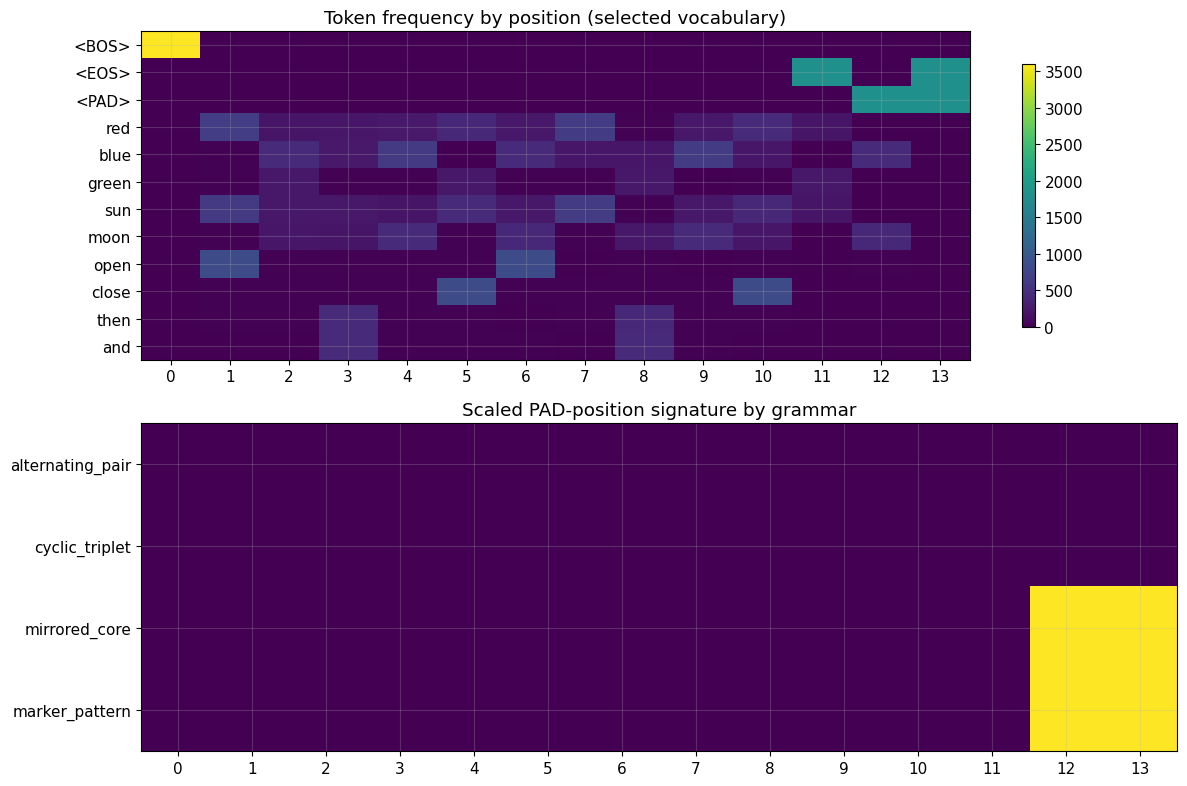

In [4]:
# Cell 4
# Visualization of sample sequences and token-position statistics

def pretty_join(tokens):
    return " ".join(tokens)

print("Representative sequences by grammar family:\n")
for gid in GRAMMAR_NAMES:
    idxs = np.where(G_train == gid)[0][:5]
    print(f"Grammar {gid} | {GRAMMAR_NAMES[gid]}")
    for idx in idxs:
        print(" noisy:", pretty_join(train_noisy[idx]))
        print(" clean:", pretty_join(train_clean[idx]))
    print()

position_counts = np.zeros((VOCAB_SIZE, MAX_LEN), dtype=np.int64)
for seq in X_train:
    for pos, tok in enumerate(seq):
        position_counts[tok, pos] += 1

top_tokens = [BOS, EOS, PAD, "red", "blue", "green", "sun", "moon", "open", "close", "then", "and"]
top_token_ids = [stoi[t] for t in top_tokens]

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

im = axes[0].imshow(position_counts[top_token_ids], aspect="auto", interpolation="nearest")
axes[0].set_yticks(range(len(top_tokens)))
axes[0].set_yticklabels(top_tokens)
axes[0].set_xticks(range(MAX_LEN))
axes[0].set_title("Token frequency by position (selected vocabulary)")
plt.colorbar(im, ax=axes[0], shrink=0.8)

grammar_matrix = np.zeros((len(GRAMMAR_NAMES), MAX_LEN), dtype=np.int64)
for gid in GRAMMAR_NAMES:
    mask = (G_train == gid)
    grammar_matrix[gid] = np.mean(X_train[mask] == stoi[PAD], axis=0) * 1000

axes[1].imshow(grammar_matrix, aspect="auto", interpolation="nearest")
axes[1].set_yticks(range(len(GRAMMAR_NAMES)))
axes[1].set_yticklabels([GRAMMAR_NAMES[k] for k in GRAMMAR_NAMES])
axes[1].set_xticks(range(MAX_LEN))
axes[1].set_title("Scaled PAD-position signature by grammar")
plt.tight_layout()
plt.show()

##5.TENSPOR PREPARATION AND DATALOADERS

###5.1.OVERVIEW

**Cell 5 Explanation**

Cell 5 prepares the sequence data for transformer training. It turns the integer arrays into PyTorch datasets and dataloaders, and it defines the causal mask used for autoregressive prediction. This is one of the most important technical transition cells in the notebook.

The first role of the cell is tensor preparation. The inputs, targets, and grammar labels are wrapped into TensorDataset objects. The inputs are integer token IDs, the targets are shifted token IDs for next-token prediction, and the grammar labels are auxiliary information used later for interpretation. This is a clean and professional way to package the data.

The dataloaders then create minibatches for training, validation, and testing. Training is shuffled, while validation and test are not. This is standard good practice and keeps training stochastic while preserving evaluation stability.

The most conceptually important piece of this cell is the causal mask function. Transformers use self-attention, and in a language model or next-token predictor the model should not look at future tokens when predicting the current one. The causal mask enforces this by blocking attention to positions ahead in the sequence. Pedagogically, this is a crucial point. Without the mask, the model could cheat by attending to future tokens, which would make the task trivial and the learned behavior meaningless.

Printing the shape of the mask helps students see that the mask is a square matrix over sequence positions. It is not a mysterious artifact but a structural rule that enforces autoregressive learning.

The decoded sample input and target printed at the end are also pedagogically valuable. They let the reader verify that the target really is the shifted next-token sequence. This is one of the most common sources of confusion in sequence modeling, so making it explicit is helpful.

Conceptually, Cell 5 is where the grammar problem becomes a formal causal language-modeling problem. The synthetic sequences are no longer just text examples; they are now aligned input-target pairs with autoregressive masking. This is the exact environment in which the transformer will learn.

So Cell 5 is best understood as the sequence-interface cell. It prepares the tensor data, enforces causal structure, and verifies that the notebook is now properly framed as a next-token prediction experiment.

###5.2.CODE AND IMPLEMENTATION

In [5]:
# Cell 5
# Tensor preparation, dataloaders, causal mask utilities, batch inspection

def make_dataset(X, Y, G):
    x = torch.tensor(X, dtype=torch.long)
    y = torch.tensor(Y, dtype=torch.long)
    g = torch.tensor(G, dtype=torch.long)
    return TensorDataset(x, y, g)

train_ds = make_dataset(X_train, Y_train, G_train)
val_ds = make_dataset(X_val, Y_val, G_val)
test_ds = make_dataset(X_test, Y_test, G_test)

BATCH_SIZE = 128
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

def causal_mask(seq_len):
    mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
    return mask

mask = causal_mask(MAX_LEN)
xb, yb, gb = next(iter(train_loader))
print("Input batch shape:", xb.shape)
print("Target batch shape:", yb.shape)
print("Grammar batch shape:", gb.shape)
print("Causal mask shape:", mask.shape)
print("Decoded sample input:", decode(xb[0].tolist()))
print("Decoded sample target:", decode(yb[0].tolist()))

Input batch shape: torch.Size([128, 14])
Target batch shape: torch.Size([128, 14])
Grammar batch shape: torch.Size([128])
Causal mask shape: torch.Size([14, 14])
Decoded sample input: ['<BOS>', 'east', 'west', 'north', 'east', 'west', 'north', 'east', 'west', 'north', 'east', 'west', 'north', '<EOS>']
Decoded sample target: ['east', 'west', 'north', 'east', 'west', 'north', 'east', 'west', 'north', 'east', 'west', 'north', '<EOS>', '<PAD>']


##6.BAYESIAN TRANSFORMER IMPLEMENTATION

###6.1.OVERVIEW

**Cell 6 Explanation**

Cell 6 is the mathematical and architectural core of the notebook because it defines the Bayesian transformer itself. This cell is the point where transformer sequence modeling and Bayesian parameter uncertainty are fused into one executable system.

The building block is the BayesianLinear layer. Just as in the Bayesian neural network notebook, each weight and bias is given a variational Gaussian representation with learnable mean and rho parameters. The rho value is transformed into a positive scale, and the actual weights used in a forward pass are sampled through the reparameterization trick. This is the fundamental Bayesian ingredient. Instead of fixed matrices, the transformer now uses sampled matrices drawn from a learned posterior approximation.

The KL-divergence method in BayesianLinear is equally important. It computes the divergence between the learned approximate posterior for the weights and a Gaussian prior. This KL term is later added to the predictive loss during training. Pedagogically, this shows that Bayesian learning is not just “noisy weights.” The model is being optimized under a principled balance between data fit and posterior complexity.

The BayesianSelfAttention module then uses Bayesian linear projections for queries, keys, values, and outputs. This is an elegant and conceptually powerful design. It means that uncertainty lives inside the attention mechanism itself. Different sampled transformers can produce slightly different query-key-value interactions, which is exactly what we want from a Bayesian attention model.

The split-heads and merge-heads functions implement the standard transformer attention reshaping. Keeping these explicit is pedagogically useful because students can see that the notebook is a real transformer, not a simplified attention toy.

The BayesianTransformerBlock adds residual structure and a Bayesian feed-forward network, again using BayesianLinear layers. This means the model’s uncertainty is distributed throughout both the attention and nonlinear transformation stages.

The final BayesianTransformerLM includes token embeddings, positional embeddings, stacked transformer blocks, a final layer normalization, and a Bayesian output head. This is a compact but real causal transformer language model.

Printing the architecture and parameter count at the end is a useful diagnostic. It shows the student how many learnable quantities the model contains and reinforces that a Bayesian model carries more variational parameters than a deterministic one.

Conceptually, Cell 6 teaches that a Bayesian transformer is not just a transformer with uncertainty tacked on at the output. It is a transformer whose internal projections and transformations are themselves uncertain. Every forward pass is one plausible transformer sampled from the posterior approximation. That is the key idea that powers the rest of the notebook.

###6.2.CODE AND IMPLEMENTATION

In [7]:
# Cell 6
# Bayesian transformer implementation

class BayesianLinear(nn.Module):
    def __init__(self, in_features, out_features, prior_sigma=1.0):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.prior_sigma = prior_sigma

        self.weight_mu = nn.Parameter(torch.empty(out_features, in_features).normal_(0, 0.02))
        self.weight_rho = nn.Parameter(torch.empty(out_features, in_features).fill_(-4.0))
        self.bias_mu = nn.Parameter(torch.zeros(out_features))
        self.bias_rho = nn.Parameter(torch.empty(out_features).fill_(-4.0))

    def sigma(self, rho):
        return torch.log1p(torch.exp(rho))

    def sample(self):
        weight_sigma = self.sigma(self.weight_rho)
        bias_sigma = self.sigma(self.bias_rho)
        eps_w = torch.randn_like(self.weight_mu)
        eps_b = torch.randn_like(self.bias_mu)
        weight = self.weight_mu + weight_sigma * eps_w
        bias = self.bias_mu + bias_sigma * eps_b
        return weight, bias, weight_sigma, bias_sigma

    def kl_divergence(self):
        weight_sigma = self.sigma(self.weight_rho)
        bias_sigma = self.sigma(self.bias_rho)
        prior_var = self.prior_sigma ** 2

        kl_w = torch.sum(
            torch.log(torch.tensor(self.prior_sigma, device=self.weight_mu.device) / weight_sigma)
            + (weight_sigma ** 2 + self.weight_mu ** 2) / (2 * prior_var)
            - 0.5
        )
        kl_b = torch.sum(
            torch.log(torch.tensor(self.prior_sigma, device=self.bias_mu.device) / bias_sigma)
            + (bias_sigma ** 2 + self.bias_mu ** 2) / (2 * prior_var)
            - 0.5
        )
        return kl_w + kl_b

    def forward(self, x):
        w, b, _, _ = self.sample()
        return F.linear(x, w, b)

class BayesianSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, prior_sigma=1.0):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_model // n_heads

        self.q_proj = BayesianLinear(d_model, d_model, prior_sigma)
        self.k_proj = BayesianLinear(d_model, d_model, prior_sigma)
        self.v_proj = BayesianLinear(d_model, d_model, prior_sigma)
        self.o_proj = BayesianLinear(d_model, d_model, prior_sigma)

    def split_heads(self, x):
        bsz, seq, dim = x.shape
        x = x.view(bsz, seq, self.n_heads, self.d_head).transpose(1, 2)
        return x

    def merge_heads(self, x):
        bsz, heads, seq, d_head = x.shape
        return x.transpose(1, 2).contiguous().view(bsz, seq, heads * d_head)

    def forward(self, x, mask):
        q = self.split_heads(self.q_proj(x))
        k = self.split_heads(self.k_proj(x))
        v = self.split_heads(self.v_proj(x))

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_head)
        scores = scores.masked_fill(mask.unsqueeze(0).unsqueeze(0).to(scores.device), float("-inf"))
        attn = torch.softmax(scores, dim=-1)
        out = torch.matmul(attn, v)
        out = self.merge_heads(out)
        out = self.o_proj(out)
        return out

    def kl_divergence(self):
        return (
            self.q_proj.kl_divergence() +
            self.k_proj.kl_divergence() +
            self.v_proj.kl_divergence() +
            self.o_proj.kl_divergence()
        )

class BayesianTransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, prior_sigma=1.0):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = BayesianSelfAttention(d_model, n_heads, prior_sigma)
        self.ln2 = nn.LayerNorm(d_model)
        self.ff1 = BayesianLinear(d_model, d_ff, prior_sigma)
        self.ff2 = BayesianLinear(d_ff, d_model, prior_sigma)

    def forward(self, x, mask):
        x = x + self.attn(self.ln1(x), mask)
        h = F.gelu(self.ff1(self.ln2(x)))
        x = x + self.ff2(h)
        return x

    def kl_divergence(self):
        return self.attn.kl_divergence() + self.ff1.kl_divergence() + self.ff2.kl_divergence()

class BayesianTransformerLM(nn.Module):
    def __init__(self, vocab_size, max_len, d_model=64, n_heads=4, d_ff=128, n_layers=2, prior_sigma=1.0):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)
        self.blocks = nn.ModuleList([
            BayesianTransformerBlock(d_model, n_heads, d_ff, prior_sigma) for _ in range(n_layers)
        ])
        self.ln_f = nn.LayerNorm(d_model)
        self.head = BayesianLinear(d_model, vocab_size, prior_sigma)
        self.max_len = max_len

    def forward(self, x, mask):
        bsz, seq_len = x.shape
        pos = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(bsz, seq_len)
        h = self.token_emb(x) + self.pos_emb(pos)
        for block in self.blocks:
            h = block(h, mask)
        h = self.ln_f(h)
        logits = self.head(h)
        return logits

    def kl_divergence(self):
        total = self.head.kl_divergence()
        for block in self.blocks:
            total = total + block.kl_divergence()
        return total

model = BayesianTransformerLM(
    vocab_size=VOCAB_SIZE,
    max_len=MAX_LEN,
    d_model=64,
    n_heads=4,
    d_ff=128,
    n_layers=2,
    prior_sigma=1.0
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print("Number of parameters:", n_params)

BayesianTransformerLM(
  (token_emb): Embedding(23, 64)
  (pos_emb): Embedding(14, 64)
  (blocks): ModuleList(
    (0-1): 2 x BayesianTransformerBlock(
      (ln1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (attn): BayesianSelfAttention(
        (q_proj): BayesianLinear()
        (k_proj): BayesianLinear()
        (v_proj): BayesianLinear()
        (o_proj): BayesianLinear()
      )
      (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (ff1): BayesianLinear()
      (ff2): BayesianLinear()
    )
  )
  (ln_f): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (head): BayesianLinear()
)
Number of parameters: 138862


##7.TRAINING LOOP

###7.1.OVERVIEW

**Cell 7 Explanation**

Cell 7 trains the Bayesian transformer. This is where the theoretical ideas from Cell 6 become an optimization process over posterior approximations rather than fixed weights.

The training loss is ELBO-style. It combines a next-token negative log-likelihood term with the KL divergence from the approximate posterior to the prior. This is the defining Bayesian training structure. The model is rewarded for predicting the next token correctly, but it is also penalized for becoming too complex or too certain without enough evidence. This balance is what distinguishes Bayesian training from standard transformer optimization.

The use of multiple Monte Carlo samples during training is very important. The notebook does not rely on one sampled transformer per minibatch and pretend that is enough. Instead, it averages the negative log-likelihood across several stochastic forward passes. This better reflects the fact that learning is happening over a distribution of models. It also reduces some variance in the loss estimate.

The token accuracy computation is also carefully designed. Padding tokens are ignored, which is correct because PAD is only a structural filler and should not count as a meaningful next-token target. This is an important practical detail in sequence modeling.

The validation evaluation function is equally instructive. It uses multiple Monte Carlo forward passes at validation time, averages their predictive probabilities, and computes token-level NLL, accuracy, and perplexity. This is exactly how Bayesian sequence evaluation should work. The model should be assessed under its posterior predictive behavior, not under a single arbitrary sampled pass.

Perplexity is a particularly nice metric here because it is a standard language-modeling measure. Students can connect Bayesian uncertainty-aware training with a familiar sequence-modeling quantity.

The epoch printout provides train_loss, train_nll, train_kl, train_token_acc, validation NLL, validation accuracy, and validation perplexity. This is pedagogically excellent because it exposes the internal structure of the optimization. Students can see whether the KL term remains meaningful, whether train and validation move together, and whether the language-modeling behavior improves steadily.

Conceptually, Cell 7 teaches that Bayesian transformer training is not simply standard transformer training plus noise. It is optimization over distributions, using stochastic forward passes and KL-regularized objectives. This is a profound conceptual shift, and this cell is where that shift becomes operational.

So Cell 7 is the notebook’s learning engine. It trains the Bayesian transformer, monitors both predictive and probabilistic components of the loss, and produces the history that later cells will interpret.

###7.2.CODE AND IMPLEMENTATION

In [8]:
# Cell 7
# Training loop with ELBO-style objective and validation tracking

EPOCHS = 18
MC_TRAIN_SAMPLES = 2
IGNORE_INDEX = stoi[PAD]
history = {
    "train_loss": [],
    "train_nll": [],
    "train_kl": [],
    "train_token_acc": [],
    "val_loss": [],
    "val_token_acc": [],
    "val_perplexity": []
}

def token_accuracy(logits, targets, ignore_index=IGNORE_INDEX):
    pred = logits.argmax(dim=-1)
    mask = (targets != ignore_index)
    correct = ((pred == targets) & mask).sum().item()
    total = mask.sum().item()
    return correct / max(total, 1)

def evaluate(loader, mc_samples=8):
    model.eval()
    total_loss = 0.0
    total_n = 0
    total_correct = 0
    total_tokens = 0

    with torch.no_grad():
        for xb, yb, _ in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            mask = causal_mask(xb.size(1)).to(DEVICE)

            probs_mc = []
            for _ in range(mc_samples):
                logits = model(xb, mask)
                probs_mc.append(torch.softmax(logits, dim=-1))
            probs = torch.stack(probs_mc, dim=0).mean(dim=0)

            log_probs = torch.log(probs + 1e-8)
            loss = F.nll_loss(log_probs.view(-1, VOCAB_SIZE), yb.view(-1), ignore_index=IGNORE_INDEX, reduction="sum")
            total_loss += loss.item()

            pred = probs.argmax(dim=-1)
            valid = (yb != IGNORE_INDEX)
            total_correct += ((pred == yb) & valid).sum().item()
            total_tokens += valid.sum().item()
            total_n += xb.size(0)

    avg_nll = total_loss / max(total_tokens, 1)
    avg_acc = total_correct / max(total_tokens, 1)
    perplexity = math.exp(avg_nll)
    return avg_nll, avg_acc, perplexity

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    running_nll = 0.0
    running_kl = 0.0
    total_correct = 0
    total_tokens = 0

    for xb, yb, _ in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        mask = causal_mask(xb.size(1)).to(DEVICE)

        optimizer.zero_grad()
        nll_accum = 0.0
        logits_last = None

        for _ in range(MC_TRAIN_SAMPLES):
            logits = model(xb, mask)
            logits_last = logits
            nll = F.cross_entropy(
                logits.view(-1, VOCAB_SIZE),
                yb.view(-1),
                ignore_index=IGNORE_INDEX
            )
            nll_accum = nll_accum + nll

        nll = nll_accum / MC_TRAIN_SAMPLES
        kl = model.kl_divergence() / len(train_ds)
        loss = nll + kl

        loss.backward()
        optimizer.step()

        valid = (yb != IGNORE_INDEX)
        pred = logits_last.argmax(dim=-1)
        total_correct += ((pred == yb) & valid).sum().item()
        total_tokens += valid.sum().item()

        running_loss += loss.item() * xb.size(0)
        running_nll += nll.item() * xb.size(0)
        running_kl += kl.item() * xb.size(0)

    train_loss = running_loss / len(train_ds)
    train_nll = running_nll / len(train_ds)
    train_kl = running_kl / len(train_ds)
    train_acc = total_correct / max(total_tokens, 1)

    val_loss, val_acc, val_ppl = evaluate(val_loader, mc_samples=10)

    history["train_loss"].append(train_loss)
    history["train_nll"].append(train_nll)
    history["train_kl"].append(train_kl)
    history["train_token_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_token_acc"].append(val_acc)
    history["val_perplexity"].append(val_ppl)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} | train_nll={train_nll:.4f} | train_kl={train_kl:.4f} | "
        f"train_token_acc={train_acc:.4f} | val_nll={val_loss:.4f} | val_token_acc={val_acc:.4f} | val_ppl={val_ppl:.3f}"
    )

Epoch 01/18 | train_loss=68.0240 | train_nll=2.3071 | train_kl=65.7168 | train_token_acc=0.4347 | val_nll=1.4048 | val_token_acc=0.6125 | val_ppl=4.075
Epoch 02/18 | train_loss=65.6202 | train_nll=0.9688 | train_kl=64.6514 | train_token_acc=0.7263 | val_nll=0.6852 | val_token_acc=0.7935 | val_ppl=1.984
Epoch 03/18 | train_loss=64.1150 | train_nll=0.5331 | train_kl=63.5819 | train_token_acc=0.8254 | val_nll=0.4805 | val_token_acc=0.8317 | val_ppl=1.617
Epoch 04/18 | train_loss=62.9227 | train_nll=0.4142 | train_kl=62.5085 | train_token_acc=0.8442 | val_nll=0.4145 | val_token_acc=0.8422 | val_ppl=1.514
Epoch 05/18 | train_loss=61.8061 | train_nll=0.3722 | train_kl=61.4339 | train_token_acc=0.8531 | val_nll=0.3884 | val_token_acc=0.8458 | val_ppl=1.475
Epoch 06/18 | train_loss=60.7102 | train_nll=0.3509 | train_kl=60.3593 | train_token_acc=0.8560 | val_nll=0.3738 | val_token_acc=0.8517 | val_ppl=1.453
Epoch 07/18 | train_loss=59.6224 | train_nll=0.3369 | train_kl=59.2855 | train_token_acc

##8.TRAINING DIAGNOSTICS

###8.1.OVERVIEW

**Cell 8 Explanation**

Cell 8 visualizes the training dynamics of the Bayesian transformer. This is important because sequence-model training can otherwise feel opaque. Printed logs are useful, but curves make learning behavior much easier to interpret.

The first subplot compares train loss and validation NLL. This gives the reader a quick sense of whether the model is learning meaningful structure without diverging or overfitting badly. In a healthy run, the train loss should fall, and validation NLL should also improve. If validation begins to worsen while training keeps improving, that would suggest overfitting or miscalibrated complexity. In a Bayesian model, this comparison is especially interesting because the training objective includes KL regularization while validation NLL reflects predictive quality under Monte Carlo averaging.

The second subplot tracks train and validation token accuracy. This is a more intuitive measure for many readers because it directly reflects the proportion of correct next-token predictions. If both curves improve together, the model is learning the grammar structure. If training accuracy far exceeds validation accuracy, that would signal poorer generalization.

The third subplot is especially pedagogical because it plots train NLL, train KL, and validation perplexity together. The train NLL captures the model’s fit to the sequence data. The train KL captures the pressure from the prior. The validation perplexity reflects how uncertain the model’s next-token predictions remain. Seeing these together helps students understand that Bayesian optimization is not one-dimensional. The model is balancing likelihood fit against posterior complexity while also trying to achieve low predictive perplexity.

Saving the history to JSON is again a sign of scientific practice. The notebook is not only visually informative but also reproducible and auditable.

Conceptually, Cell 8 reinforces a central lesson: optimization behavior matters. A Bayesian transformer should not be judged only by the final token accuracy. One should also ask whether training stabilized, whether the KL term collapsed or remained active, and whether validation improved in step with training. Those questions help distinguish healthy Bayesian learning from brittle optimization.

So Cell 8 is the training-interpretation cell. It turns raw history into meaningful learning curves and teaches the student how to read Bayesian transformer optimization as a structured process rather than a black box.

###8.2.CODE AND IMPLEMENTATION

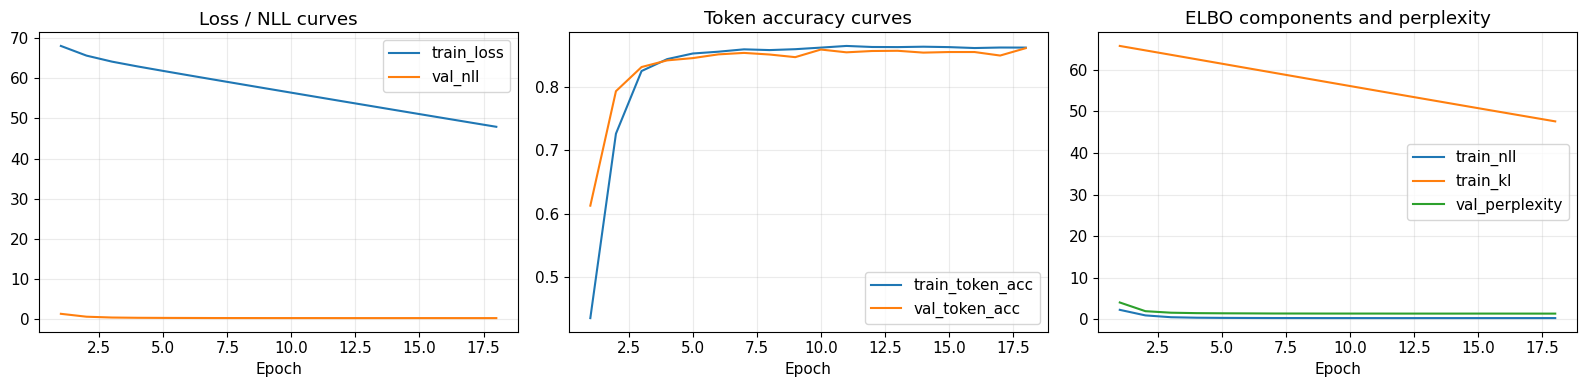

Saved training history.


In [9]:
# Cell 8
# Training diagnostics and visualization of optimization behavior

epochs = np.arange(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs, history["train_loss"], label="train_loss")
axes[0].plot(epochs, history["val_loss"], label="val_nll")
axes[0].set_title("Loss / NLL curves")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs, history["train_token_acc"], label="train_token_acc")
axes[1].plot(epochs, history["val_token_acc"], label="val_token_acc")
axes[1].set_title("Token accuracy curves")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(epochs, history["train_nll"], label="train_nll")
axes[2].plot(epochs, history["train_kl"], label="train_kl")
axes[2].plot(epochs, history["val_perplexity"], label="val_perplexity")
axes[2].set_title("ELBO components and perplexity")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.tight_layout()
plt.show()

with open(ARTIFACT_DIR / "training_history.json", "w") as f:
    json.dump(history, f, indent=2)

print("Saved training history.")

##9.MONTECARLO TEST INFERENCE

###9.1.0VERVIEW

**Cell 9 Explanation**

Cell 9 performs full Bayesian evaluation on the test set. This is where the notebook reveals how the transformer behaves as a posterior predictive sequence model rather than just a trained network.

The mc_predict function is the key mechanism. For each test batch, it performs many stochastic forward passes through the Bayesian transformer, each one sampling a different set of attention and feed-forward weights from the learned posterior approximation. The resulting next-token probabilities are averaged. This Monte Carlo averaging is what makes the evaluation genuinely Bayesian. Instead of relying on one frozen model, the notebook asks many plausible transformers for their predictions and aggregates them.

The outputs of this process are rich. We get predicted tokens, full predictive probability distributions, predictive entropy, and predictive confidence for every token position. This is a major conceptual gain over standard evaluation. The model is not only judged by whether it predicts correctly, but also by how certain it is.

Token accuracy, NLL, and perplexity are computed over valid non-PAD tokens. This is appropriate sequence-model practice. Accuracy tells us how often the top token is right. NLL and perplexity evaluate the full predictive distribution, which is especially important in a Bayesian notebook because probabilities matter, not only argmax decisions.

The confusion matrix is built for the final valid token in each sequence, which is a nice interpretive simplification. Full token-level confusion across all positions could be too large and messy. By focusing on a selected interpretable position, the notebook makes class confusion easier to visualize.

The entropy and confidence histograms are also pedagogically very valuable. They show the spread of uncertainty across the test corpus. If entropy is low for most valid tokens, the model is usually decisive. If entropy has a longer tail, then some prefixes remain structurally ambiguous. The confidence histogram complements that by showing how concentrated the maximum probabilities are.

Conceptually, Cell 9 teaches that Bayesian evaluation of a language model is a study of predictive distributions, not just final tokens. The model’s uncertainty becomes an explicit object of analysis. That is the real scientific payoff of using a Bayesian transformer.

So Cell 9 is the posterior-predictive evaluation cell. It quantifies how well the model predicts, how uncertain it is, and how its next-token errors are structured.

###9.2.CODE AND IMPLEMENTATION

Test token accuracy: 0.8567
Test NLL: 0.3537
Test perplexity: 1.4243
Mean predictive entropy: 0.408


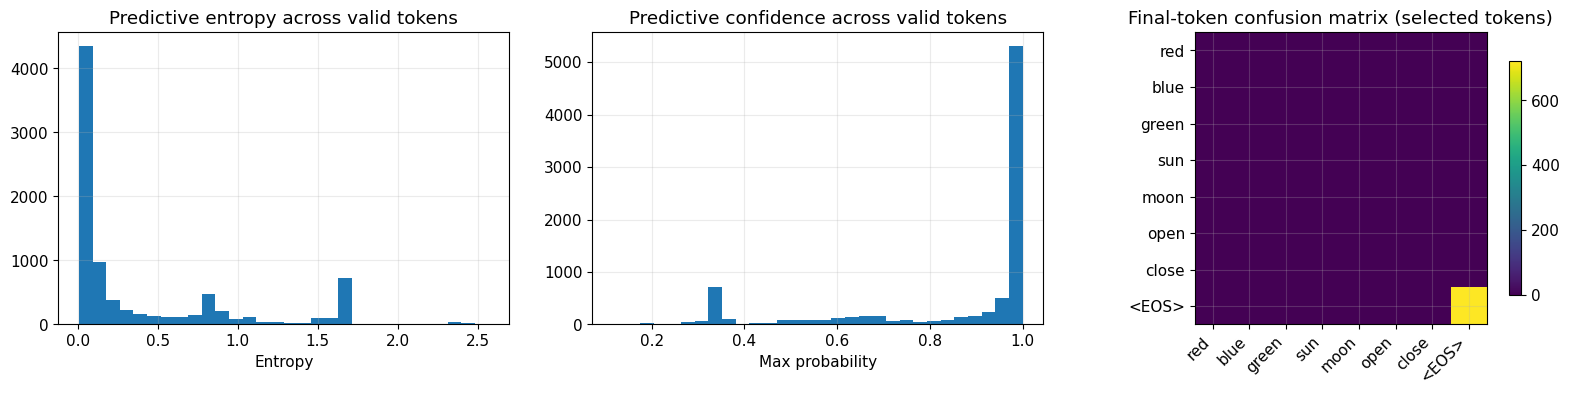

In [10]:
# Cell 9
# Monte Carlo test-time inference, next-token metrics, uncertainty computation, confusion matrix

def mc_predict(loader, mc_samples=30):
    model.eval()
    all_inputs = []
    all_targets = []
    all_grammars = []
    all_probs = []

    with torch.no_grad():
        for xb, yb, gb in loader:
            xb = xb.to(DEVICE)
            mask = causal_mask(xb.size(1)).to(DEVICE)

            probs_mc = []
            for _ in range(mc_samples):
                logits = model(xb, mask)
                probs_mc.append(torch.softmax(logits, dim=-1))
            probs = torch.stack(probs_mc, dim=0).mean(dim=0)

            all_inputs.append(xb.cpu().numpy())
            all_targets.append(yb.numpy())
            all_grammars.append(gb.numpy())
            all_probs.append(probs.cpu().numpy())

    X = np.concatenate(all_inputs, axis=0)
    Y = np.concatenate(all_targets, axis=0)
    G = np.concatenate(all_grammars, axis=0)
    P = np.concatenate(all_probs, axis=0)
    Pred = P.argmax(axis=-1)
    Ent = -np.sum(P * np.log(P + 1e-12), axis=-1)
    Conf = P.max(axis=-1)
    return X, Y, G, Pred, P, Ent, Conf

X_te, Y_te, G_te, Pred_te, Prob_te, Ent_te, Conf_te = mc_predict(test_loader, mc_samples=40)

valid = (Y_te != IGNORE_INDEX)
token_acc = float((Pred_te[valid] == Y_te[valid]).mean())

nll = -np.log(np.take_along_axis(Prob_te, Y_te[..., None], axis=-1).squeeze(-1) + 1e-12)
test_nll = float(nll[valid].mean())
test_ppl = float(math.exp(test_nll))
mean_entropy = float(Ent_te[valid].mean())

# Focus confusion on final non-PAD target position for interpretability
final_positions = []
true_final = []
pred_final = []
for i in range(len(Y_te)):
    pos = np.where(Y_te[i] != IGNORE_INDEX)[0][-1]
    final_positions.append(pos)
    true_final.append(int(Y_te[i, pos]))
    pred_final.append(int(Pred_te[i, pos]))
true_final = np.array(true_final)
pred_final = np.array(pred_final)

cm = np.zeros((VOCAB_SIZE, VOCAB_SIZE), dtype=int)
for a, b in zip(true_final, pred_final):
    cm[a, b] += 1

selected_token_ids = [stoi[t] for t in ["red", "blue", "green", "sun", "moon", "open", "close", EOS]]
cm_small = cm[np.ix_(selected_token_ids, selected_token_ids)]

print("Test token accuracy:", round(token_acc, 4))
print("Test NLL:", round(test_nll, 4))
print("Test perplexity:", round(test_ppl, 4))
print("Mean predictive entropy:", round(mean_entropy, 4))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(Ent_te[valid], bins=30)
axes[0].set_title("Predictive entropy across valid tokens")
axes[0].set_xlabel("Entropy")

axes[1].hist(Conf_te[valid], bins=30)
axes[1].set_title("Predictive confidence across valid tokens")
axes[1].set_xlabel("Max probability")

im = axes[2].imshow(cm_small, interpolation="nearest")
axes[2].set_title("Final-token confusion matrix (selected tokens)")
axes[2].set_xticks(range(len(selected_token_ids)))
axes[2].set_yticks(range(len(selected_token_ids)))
axes[2].set_xticklabels([itos[i] for i in selected_token_ids], rotation=45, ha="right")
axes[2].set_yticklabels([itos[i] for i in selected_token_ids])
plt.colorbar(im, ax=axes[2], shrink=0.8)

plt.tight_layout()
plt.show()

##10.ADVANCED VISUALIZATION

###10.1.OVERVIEW

**Cell 10 Explanation**

Cell 10 is one of the richest interpretive cells in the notebook because it moves from aggregate statistics to concrete prefix-level case studies. This is especially valuable in sequence modeling, where uncertainty can depend strongly on local context.

The cell selects three kinds of examples: highly confident correct cases, highly uncertain cases, and mispredicted cases. This is an excellent pedagogical strategy because it gives the student three different windows into the model’s behavior. Confident correct cases show what the transformer has clearly learned. Uncertain cases show where the grammar and corruption create ambiguity. Mispredicted cases show how the model fails and whether those failures are understandable.

For each example, the notebook displays the grammar family, the actual prefix tokens, the true next token, the predicted next token, the confidence, and the entropy. This is extremely useful because it anchors uncertainty directly in an interpretable context. The student can look at the prefix and ask: does the uncertainty make sense? Does the wrong prediction reflect severe corruption, grammar overlap, or genuine confusion?

The probability bar chart for the next-token vocabulary is perhaps the most important visual here. It lets the reader see not just which token won, but what the alternatives were. This is where Bayesian sequence modeling becomes truly informative. A wrong prediction with a nearly tied correct token and predicted token tells a different story from a wrong prediction with one token overwhelmingly dominant. Likewise, a high-entropy correct prediction suggests that the model got the answer right but recognized that the case was difficult.

This cell also reinforces an important scientific lesson: local examples matter. Aggregate metrics can tell us how well the model performs overall, but deep understanding often comes from studying specific prefixes. In a Bayesian notebook, that is especially true because posterior uncertainty is inherently local. Different prefixes induce different degrees of posterior predictive agreement among sampled transformers.

So Cell 10 is the notebook’s case-study interpretation cell. It connects sequence structure, prediction, and uncertainty in a concrete, readable way and helps students learn how to inspect a Bayesian transformer scientifically rather than just numerically.

###10.2.CODE AND IMPLEMENTATION

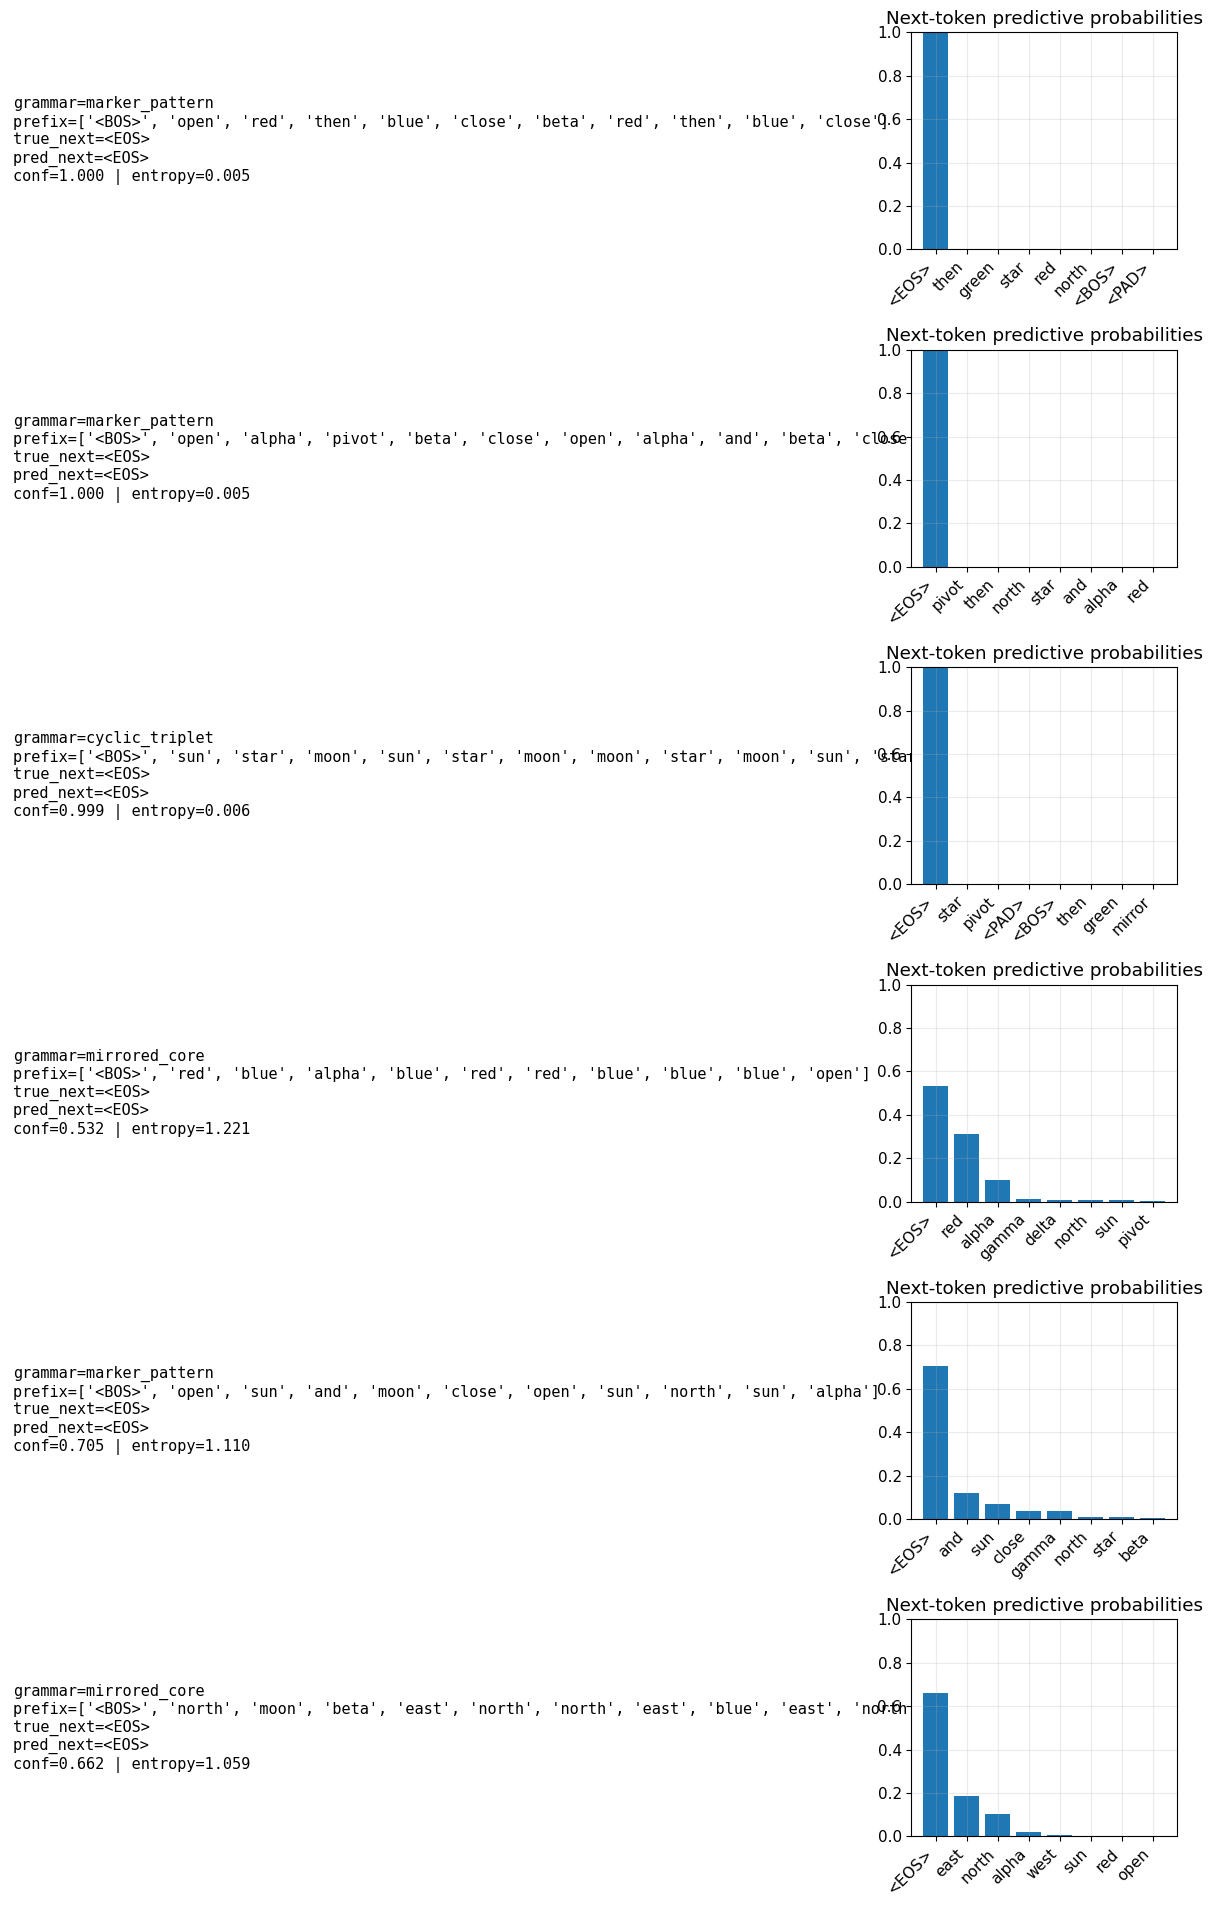

In [11]:
# Cell 10
# Advanced visualization of selected prefixes and next-token predictive bars

# Select one target position per sequence: final valid token
example_info = []
for i in range(len(X_te)):
    pos = np.where(Y_te[i] != IGNORE_INDEX)[0][-1]
    example_info.append({
        "index": i,
        "pos": int(pos),
        "grammar": int(G_te[i]),
        "entropy": float(Ent_te[i, pos]),
        "confidence": float(Conf_te[i, pos]),
        "true_token": int(Y_te[i, pos]),
        "pred_token": int(Pred_te[i, pos])
    })

correct = [e for e in example_info if e["true_token"] == e["pred_token"]]
wrong = [e for e in example_info if e["true_token"] != e["pred_token"]]

confident_correct = sorted(correct, key=lambda x: -x["confidence"])[:3]
uncertain_cases = sorted(example_info, key=lambda x: -x["entropy"])[:3]
mispred_cases = sorted(wrong, key=lambda x: -x["confidence"])[:3]

selected = confident_correct + uncertain_cases + mispred_cases
if len(selected) == 0:
    selected = example_info[:6]

fig, axes = plt.subplots(len(selected), 2, figsize=(12, 3.2 * len(selected)))
if len(selected) == 1:
    axes = np.array([axes])

for row, ex in enumerate(selected):
    i = ex["index"]
    pos = ex["pos"]
    prefix = decode(X_te[i][:pos + 1].tolist())
    true_tok = itos[ex["true_token"]]
    pred_tok = itos[ex["pred_token"]]
    grammar_name = GRAMMAR_NAMES[ex["grammar"]]

    axes[row, 0].axis("off")
    text = (
        f"grammar={grammar_name}\n"
        f"prefix={prefix}\n"
        f"true_next={true_tok}\n"
        f"pred_next={pred_tok}\n"
        f"conf={ex['confidence']:.3f} | entropy={ex['entropy']:.3f}"
    )
    axes[row, 0].text(0.01, 0.5, text, fontsize=11, va="center", family="monospace")

    probs = Prob_te[i, pos]
    topk = np.argsort(-probs)[:8]
    axes[row, 1].bar(np.arange(len(topk)), probs[topk])
    axes[row, 1].set_xticks(np.arange(len(topk)))
    axes[row, 1].set_xticklabels([itos[int(t)] for t in topk], rotation=45, ha="right")
    axes[row, 1].set_ylim(0, 1.0)
    axes[row, 1].set_title("Next-token predictive probabilities")

plt.tight_layout()
plt.show()

## 11.EXPLANATION

###11.1.OVERVIEW

**Cell 11 Explanation**

Cell 11 closes the notebook by summarizing the experiment in a structured and reproducible way. It is the reporting and synthesis cell, and pedagogically it teaches students how a serious Bayesian machine learning notebook should end.

The first major contribution of this cell is the grammar-family summary. Instead of reporting only overall token accuracy, the notebook computes sequence counts, token accuracy, mean entropy, and mean confidence for each grammar family separately. This is very important because the task is heterogeneous. Some grammars may be easier than others. Alternating pairs may be simpler than mirrored structures. Marker-based patterns may be robust or fragile depending on corruption. By reporting classwise summaries, the notebook reveals those differences instead of hiding them inside one global average.

The results dictionary then gathers the core experiment information into one object: seed, device, vocabulary size, maximum sequence length, overall test metrics, familywise summaries, final training and validation performance, and confusion-matrix subsets. This is excellent practice because it creates a clean artifact that can be saved, reused, and interpreted later.

Saving the results as JSON reinforces the notebook’s reproducibility. A student or researcher can revisit the exact outputs without rerunning the whole notebook.

The printed interpretation is concise but useful. It turns the metrics into a first-pass narrative. If token accuracy is strong and entropy is low, the notebook says the Bayesian transformer learned the grammar families decisively. If uncertainty remains meaningful, it says so. This is a good bridge between quantitative output and qualitative explanation.

The list of most uncertain final-token cases is also valuable. It highlights the exact sequence contexts in which the model remained least certain. This turns uncertainty into an inspectable object rather than a hidden scalar summary.

Conceptually, Cell 11 teaches that the end of a Bayesian transformer experiment is not just “the model reached a certain accuracy.” It is a structured statement about predictive quality, uncertainty, grammar-specific behavior, and saved scientific artifacts.

So Cell 11 is the notebook’s synthesis cell. It turns the entire sequence-model experiment into a coherent summary and preserves its results in a form suitable for later analysis, explanation, or extension.

###11.2.CODE AND IMPLEMENTATION

In [12]:
# Cell 11
# Compact research-summary cell in Python only

family_summary = {}
for gid in GRAMMAR_NAMES:
    mask_seq = (G_te == gid)
    mask_tok = np.repeat(mask_seq[:, None], Y_te.shape[1], axis=1) & valid
    family_summary[GRAMMAR_NAMES[gid]] = {
        "count_sequences": int(mask_seq.sum()),
        "token_accuracy": float((Pred_te[mask_tok] == Y_te[mask_tok]).mean()),
        "mean_entropy": float(Ent_te[mask_tok].mean()),
        "mean_confidence": float(Conf_te[mask_tok].mean())
    }

results = {
    "seed": SEED,
    "device": str(DEVICE),
    "vocab_size": VOCAB_SIZE,
    "max_len": MAX_LEN,
    "grammar_names": GRAMMAR_NAMES,
    "test_token_accuracy": token_acc,
    "test_nll": test_nll,
    "test_perplexity": test_ppl,
    "mean_predictive_entropy": mean_entropy,
    "family_summary": family_summary,
    "final_train_token_acc": float(history["train_token_acc"][-1]),
    "final_val_token_acc": float(history["val_token_acc"][-1]),
    "confusion_matrix_selected_tokens": cm_small.tolist(),
    "selected_confusion_tokens": [itos[i] for i in selected_token_ids]
}

with open(ARTIFACT_DIR / "bayesian_transformer_results.json", "w") as f:
    json.dump(results, f, indent=2)

print(json.dumps(results, indent=2))

print("\nINTERPRETATION")
if token_acc > 0.90 and mean_entropy < 0.40:
    print("The Bayesian transformer learned the synthetic grammars strongly and remained fairly decisive on next-token prediction.")
elif token_acc > 0.80:
    print("The Bayesian transformer captured the main grammar families, but uncertainty remains meaningful in corrupted or overlapping prefixes.")
else:
    print("The current Bayesian transformer is still underfitting or the sequence corruption level creates substantial ambiguity.")

most_uncertain = sorted(example_info, key=lambda x: -x["entropy"])[:5]
print("\nMost uncertain final-token cases:")
for ex in most_uncertain:
    i = ex["index"]
    pos = ex["pos"]
    print(
        f"idx={i} | grammar={GRAMMAR_NAMES[ex['grammar']]} | "
        f"prefix={' '.join(decode(X_te[i][:pos+1].tolist()))} | "
        f"true={itos[ex['true_token']]} | pred={itos[ex['pred_token']]} | "
        f"conf={ex['confidence']:.4f} | entropy={ex['entropy']:.4f}"
    )

print("\nSaved:", ARTIFACT_DIR / "bayesian_transformer_results.json")

{
  "seed": 321,
  "device": "cpu",
  "vocab_size": 23,
  "max_len": 14,
  "grammar_names": {
    "0": "alternating_pair",
    "1": "cyclic_triplet",
    "2": "mirrored_core",
    "3": "marker_pattern"
  },
  "test_token_accuracy": 0.856712962962963,
  "test_nll": 0.35368162393569946,
  "test_perplexity": 1.4243016507323194,
  "mean_predictive_entropy": 0.4079502522945404,
  "family_summary": {
    "alternating_pair": {
      "count_sequences": 180,
      "token_accuracy": 0.8474358974358974,
      "mean_entropy": 0.3691246211528778,
      "mean_confidence": 0.870543360710144
    },
    "cyclic_triplet": {
      "count_sequences": 180,
      "token_accuracy": 0.8478632478632478,
      "mean_entropy": 0.37985098361968994,
      "mean_confidence": 0.8722516298294067
    },
    "mirrored_core": {
      "count_sequences": 180,
      "token_accuracy": 0.8373737373737373,
      "mean_entropy": 0.4555930197238922,
      "mean_confidence": 0.8377029895782471
    },
    "marker_pattern": {
    

##12.CONCLUSION

**Conclusion**

This notebook demonstrates that Bayesian transformers provide a compelling way to study sequence prediction when uncertainty matters. By combining a compact causal transformer architecture with Bayesian linear projections and variational weight distributions, the notebook turns next-token prediction into a problem of posterior predictive inference rather than deterministic scoring. That shift is the deepest lesson of the exercise. The model does not merely learn one set of parameters and then speak as though it were certain. Instead, it learns an approximate posterior over plausible parameter settings and makes predictions by averaging over them. This changes the meaning of prediction from a single answer to a distribution of plausible answers shaped by both the data and the model’s own uncertainty.

The synthetic grammar setting makes this especially clear. Because the sequence families are controlled and interpretable, we can see exactly what kinds of regularities the transformer is asked to capture. Alternating pairs, cyclic triplets, mirrored structures, and marker-based patterns each express a different kind of sequence logic. Some are highly local. Some require remembering longer-range structure. Some use structural framing. This already makes the transformer architecture a natural fit, since self-attention is designed to compare and combine information across sequence positions. But once corruption is introduced, the task becomes more interesting. Now the model must predict the next token from evidence that is incomplete, noisy, or partially misleading. That is the perfect environment in which Bayesian uncertainty can become meaningful.

One of the strongest insights from the notebook is that uncertainty in sequence prediction should be treated as part of the result, not merely as a side effect. In deterministic language modeling, we often look at the top predicted token and perhaps the softmax distribution, but those outputs can hide the fact that the model parameters themselves may not strongly support one continuation over another. In the Bayesian transformer, multiple sampled versions of the model see the same prefix and may disagree. When they do, predictive entropy increases. This gives us a more honest representation of what the model has really learned. A prefix may lead to a confident continuation because the grammar is strong and corruption mild. Another prefix may lead to several plausible next tokens because the sequence has been disturbed or because grammar families overlap. The Bayesian transformer makes that distinction visible.

Another major lesson is that Bayesian sequence modeling helps us think more carefully about what confidence means. In ordinary sequence models, a sharp probability distribution can create the impression that the model “knows” the answer. But that sharpness may be conditional on one fixed parameter setting. In a Bayesian transformer, confidence is not merely a property of the final softmax. It is the result of agreement across many plausible sampled transformers. This is a much stronger notion. It means that high confidence is supported not just by one model realization, but by posterior consensus. Conversely, uncertainty is not just a vague weakness. It is a sign that plausible models disagree or that the evidence is insufficiently constraining. That is a more mature and more scientifically useful concept of confidence.

The training process also teaches an important lesson about Bayesian optimization. The model is not simply minimizing next-token cross-entropy. It is balancing data fit against KL divergence to a prior. This means that the model is encouraged to explain the synthetic corpus well, but only with as much complexity and certainty as the evidence supports. This is one of the most attractive features of Bayesian deep learning. It turns the idea of regularization into a probabilistic principle. The model cannot become arbitrarily certain for free. It must “pay” KL cost to move away from prior simplicity. In educational terms, this is a beautiful example of how Bayesian reasoning reshapes deep learning from inside rather than from outside.

The notebook also shows how crucial visualization is for understanding Bayesian transformers. Sequence models can easily become black boxes because much of their action happens in embeddings, projections, and hidden states. But the notebook uses sequence printouts, token-position heatmaps, training curves, entropy histograms, confidence distributions, confusion matrices, and case-study prefix analyses to make the model behavior visible. This is not ornamental. It is central. A Bayesian model produces rich outputs, and those outputs deserve rich diagnostics. Without visualization, the notebook would still run, but much of its conceptual value would be lost.

A particularly important contribution of the notebook is its demonstration that synthetic data are powerful teaching tools for advanced probabilistic models. In some contexts, synthetic data are wrongly dismissed as too simple. But for understanding Bayesian transformers, simplicity is a major advantage. Because the grammar families are known, because corruption is controlled, and because the labels are clean, one can study how uncertainty emerges under specific structural conditions. This is much harder in real-world language, where ambiguity, style, semantics, and data quality are all mixed together. The synthetic setup lets us isolate mechanism. That makes the notebook scientifically cleaner and pedagogically stronger.

At the same time, the notebook encourages humility. The posterior here is approximate. The transformer is small. The variational family is simple. The synthetic text world is far simpler than natural language. These are important limitations. They mean the notebook should not be mistaken for a production language model or a definitive solution to uncertainty in large transformers. But those limitations do not reduce its value. Instead, they clarify its role: this is a laboratory for understanding principles. It teaches what it means to put distributions over transformer weights, what it means to sample multiple plausible self-attention systems, and what it means to interpret predictive entropy in a sequence setting.

There is also a broader lesson about where Bayesian transformers might matter beyond this notebook. Many sequence problems in real applications involve uncertainty of the exact kind illustrated here. In finance, token-like sequences may represent market events, transaction streams, event-state transitions, or structured symbolic encodings of market conditions. In operations, they may represent logs, command sequences, or machine states. In medicine, they may represent clinical event histories. In all such domains, one may care not just about the most likely next event but also about how uncertain the model is about the continuation. A deterministic transformer can predict. A Bayesian transformer can predict while also expressing how stable that prediction is under posterior variation.

This distinction becomes especially important when decisions depend on confidence. A model that is slightly less accurate on average but much more honest about when it is uncertain can be more useful than a model that is sharply confident everywhere. Bayesian transformers therefore matter not only because they extend transformer modeling mathematically, but because they improve the epistemic quality of the model’s outputs. They allow downstream users to distinguish between strong evidence and weak evidence, between stable continuation and ambiguous continuation, and between learned pattern and fragile guess.

Another enduring takeaway from the notebook is that Bayesian deep learning is not a separate world disconnected from practical coding. The notebook shows that with only basic libraries, a carefully designed synthetic corpus, Bayesian linear layers, causal attention, KL regularization, and Monte Carlo prediction, one can build a serious uncertainty-aware sequence model in Colab. This is empowering. It means that advanced probabilistic sequence modeling can be taught and explored in a compact and inspectable form.

Ultimately, the notebook does something more ambitious than just predicting synthetic tokens. It changes how we think about what sequence learning is. Instead of asking only, “What token comes next?” it asks, “What token comes next, and how certain should a model be about that answer given the evidence and the remaining uncertainty about its own parameters?” That is a deeper question, and it is one that modern AI increasingly needs to answer.

So the real value of the Bayesian transformer notebook is not only technical. It is conceptual. It shows that transformers, which are often treated as highly capable but opaque machines, can be reimagined as probabilistic systems that carry uncertainty through their internal projections and into their final predictions. It shows that synthetic sequence structure can be enough to study these ideas rigorously. And it shows that uncertainty is not a defect to be hidden but a form of information to be measured, visualized, and interpreted.

That is why Bayesian transformers matter. They do not just extend the transformer architecture. They make it more honest.